# Anomaly Detection — Two-Stage Ensemble (Known-Type Specialist + Unsupervised Generaliser)

## Strategy
The training labels cover **four known anomaly types** (in `first_batch_with_labels` and `second_batch_with_labels`).  
The test set contains a **fifth, unknown anomaly type** that the supervised model has never seen.

We address this with a **two-stage ensemble**:

1. **Stage 1 — Known-type specialist (supervised)**  
   A calibrated LightGBM + Logistic Regression stack, trained on all labelled data.  
   This arm excels at the four known patterns but may miss the novel type.

2. **Stage 2 — Novel-type generaliser (unsupervised)**  
   A blended unsupervised score from **LOF** (local density) + **Isolation Forest** (global isolation) + **SVD reconstruction error** (latent-space deviation).  
   These signals are model-free and can detect any statistical outlier, including unknown anomaly types.

3. **Meta-learner**  
   A logistic regression that learns the optimal blend of Stage 1 and Stage 2 scores using out-of-fold cross-validation — no information leakage.

### Why this beats soft-voting
- Fixed-weight averaging treats every user the same; the meta-learner can learn "trust Stage 1 when it is confident, fall back to Stage 2 otherwise."
- The unsupervised blend captures unseen anomaly patterns that the supervised arm will assign low scores.


## 1. Imports & Data Loading

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, roc_curve, precision_recall_curve,
    average_precision_score, classification_report
)
from sklearn.ensemble import (
    GradientBoostingClassifier, IsolationForest,
    StackingClassifier, VotingClassifier
)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import LedoitWolf
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics.pairwise import cosine_similarity
import os

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
    print("LightGBM available ✓")
except ImportError:
    print("LightGBM not installed — run: pip install lightgbm")
    LGBM_AVAILABLE = False

# ── Load training data ────────────────────────────────────────────────────────
data_folder = '/kaggle/input/datasets/victoriaquek/pml-data'

data_1 = np.load(os.path.join(data_folder, 'first_batch_with_labels.npz'))
data_2 = np.load(os.path.join(data_folder, 'second_batch_with_labels.npz'))
data_3 = np.load(os.path.join(data_folder, 'training_batch_with_labels.npz'))

# Combine all three labelled batches
X_raw = np.concatenate([data_1['X'], data_2['X'], data_3['X']], axis=0)
y_raw = np.concatenate([data_1['y'], data_2['y'], data_3['y']], axis=0)

print(f"Combined training interactions : {X_raw.shape[0]:,}")
print(f"Combined users                 : {len(np.unique(X_raw[:, 0]))}")
print(f"Anomalous users                : {np.sum(y_raw[:, 1] == 1)}")
print(f"Normal users                   : {np.sum(y_raw[:, 1] == 0)}")


LightGBM available ✓
Combined training interactions : 479,433
Combined users                 : 3060
Anomalous users                : 260
Normal users                   : 2800


## 2. Feature Engineering

In [2]:
# ── Shared handcrafted-feature function ──────────────────────────────────────
def compute_handcrafted_features(df, recon_error=None):
    """
    Per-user behavioural features from [user, item, rating] interactions.
    Appends recon_error as the last column if provided.
    """
    item_means      = df.groupby('item')['rating'].mean()
    df = df.copy()
    df['deviation'] = df['rating'] - df['item'].map(item_means)

    agg = df.groupby('user').agg(
        num_ratings     = ('rating', 'count'),
        mean_rating     = ('rating', 'mean'),
        std_rating      = ('rating', 'std'),
        num_items       = ('item',   'nunique'),
        pct_extreme     = ('rating', lambda r: ((r == 0) | (r == 5)).mean()),
        pct_zero        = ('rating', lambda r: (r == 0).mean()),
        pct_five        = ('rating', lambda r: (r == 5).mean()),
        rating_skewness = ('rating', lambda r: r.skew()),
        rating_kurtosis = ('rating', lambda r: r.kurtosis()),
        median_rating   = ('rating', 'median'),
        item_entropy    = ('item',   lambda x: -(
            pd.Series(x.value_counts(normalize=True)) *
            np.log2(pd.Series(x.value_counts(normalize=True)) + 1e-9)
        ).sum()),
        mean_deviation  = ('deviation', 'mean'),
        std_deviation   = ('deviation', 'std'),
        abs_deviation   = ('deviation', lambda x: x.abs().mean()),
        gini_items      = ('item', lambda x: 1 - sum(
            pd.Series(x).value_counts(normalize=True)**2)),
        pct_low         = ('rating', lambda r: (r < 3).mean()),
        # ── NEW: burst behaviour (anomalies often rate in tight time windows) ─
        # Approximated via rating concentration on a small item subset
        top5_item_pct   = ('item',   lambda x: x.value_counts(normalize=True).head(5).sum()),
        rating_range    = ('rating', lambda r: r.max() - r.min()),
    ).fillna(0)

    if recon_error is not None:
        agg['recon_error'] = recon_error.reindex(agg.index).fillna(0)

    return agg


# ── Build user-item matrix & labels ──────────────────────────────────────────
interactions = pd.DataFrame(X_raw, columns=['user', 'item', 'rating'])
labels_df    = pd.DataFrame(y_raw, columns=['user', 'label'])
labels_df    = labels_df.drop_duplicates(subset='user', keep='last')

user_item = interactions.pivot_table(
    index='user', columns='item', values='rating', aggfunc='mean'
).fillna(0)

labels_df = labels_df.set_index('user').loc[user_item.index].reset_index()
y = labels_df['label'].values

print(f"User-item matrix : {user_item.shape}")
print(f"Labels           : {y.shape}  |  balance {np.bincount(y)}")

# ── SVD reconstruction error ─────────────────────────────────────────────────
N_RECON = 30
_svd_recon = TruncatedSVD(n_components=N_RECON, random_state=42)
_ui         = user_item.values
_approx     = _svd_recon.fit_transform(_ui) @ _svd_recon.components_
recon_error = pd.Series(
    np.mean((_ui - _approx) ** 2, axis=1),
    index=user_item.index, name='recon_error'
)
print(f"Recon error — normal: {recon_error[y==0].mean():.4f}  "
      f"anomaly: {recon_error[y==1].mean():.4f}")

# ── Handcrafted features ──────────────────────────────────────────────────────
agg = compute_handcrafted_features(interactions, recon_error=recon_error)
agg = agg.loc[user_item.index]

# ── Cosine similarity to mean-normal user ────────────────────────────────────
normal_mask     = (y == 0)
mean_normal_vec = user_item.values[normal_mask].mean(axis=0, keepdims=True)
cos_sim         = cosine_similarity(user_item.values, mean_normal_vec).ravel()
agg['cosine_sim_to_normal'] = pd.Series(cos_sim, index=user_item.index)

# ── Mahalanobis distance ──────────────────────────────────────────────────────
lw = LedoitWolf().fit(agg.values[normal_mask])
mahal = np.sqrt(lw.mahalanobis(agg.values))
agg['mahal_dist'] = pd.Series(mahal, index=agg.index)

N_HANDCRAFTED = agg.shape[1]

# ── Raw combined feature matrix ───────────────────────────────────────────────
X_base = np.hstack([user_item.values, agg.values])
print(f"Feature matrix : {X_base.shape}  "
      f"({user_item.shape[1]} user-item + {N_HANDCRAFTED} handcrafted)")


User-item matrix : (3060, 998)
Labels           : (3060,)  |  balance [2800  260]
Recon error — normal: 0.7511  anomaly: 0.8854
Feature matrix : (3060, 1019)  (998 user-item + 21 handcrafted)


## 3. Custom Transformers

In [3]:
# ── SVDPlusHandcrafted: compress user-item block, pass through handcrafted ───
class SVDPlusHandcrafted(BaseEstimator, TransformerMixin):
    """TruncatedSVD on the user-item block; handcrafted columns pass through."""
    def __init__(self, n_components=50, n_handcrafted=None):
        self.n_components  = n_components
        self.n_handcrafted = n_handcrafted   # set at construction; None → use global

    def _nhc(self):
        return N_HANDCRAFTED if self.n_handcrafted is None else self.n_handcrafted

    def fit(self, X, y=None):
        self.svd_ = TruncatedSVD(n_components=self.n_components, random_state=42)
        self.svd_.fit(X[:, :-self._nhc()])
        return self

    def transform(self, X):
        svd_part  = self.svd_.transform(X[:, :-self._nhc()])
        hand_part = X[:, -self._nhc():]
        return np.hstack([svd_part, hand_part])


print("Custom transformers defined ✓")


Custom transformers defined ✓


## 4. Stage 2 — Unsupervised Generaliser Scores

Three complementary unsupervised detectors are fitted **on normal users only** to establish a clean reference distribution.  
Their scores are blended with equal weights into a single `unsup_score` column.

| Detector | Signal captured |
|---|---|
| **LOF** | Local density drop — users in sparse neighbourhoods |
| **Isolation Forest** | Global isolation — users that split off easily |
| **SVD recon error** | Latent-space deviation — users poorly explained by normal behaviour |


In [4]:
# ── LOF: fit on NORMAL users only ────────────────────────────────────────────
print("Fitting LOF (normal users only) ...")
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.09,
    novelty=True,
    n_jobs=-1,
)
lof.fit(X_base[normal_mask])
lof_scores = -lof.score_samples(X_base)   # negate: higher = more anomalous

print(f"  LOF  — normal: {lof_scores[normal_mask].mean():.4f}  "
      f"anomaly: {lof_scores[~normal_mask].mean():.4f}")

# ── Isolation Forest: fit on NORMAL users only ───────────────────────────────
print("Fitting Isolation Forest (normal users only) ...")
iso = IsolationForest(
    n_estimators=300,
    contamination=0.09,
    max_samples='auto',
    random_state=42,
    n_jobs=-1,
)
iso.fit(X_base[normal_mask])
iso_scores = -iso.score_samples(X_base)   # negate: higher = more anomalous

print(f"  ISO  — normal: {iso_scores[normal_mask].mean():.4f}  "
      f"anomaly: {iso_scores[~normal_mask].mean():.4f}")

# ── Normalise each signal to [0,1] using normal-user percentiles ──────────────
# def percentile_normalise(scores, ref_mask):
#     """Scale scores so the 1st–99th percentile of ref_mask spans [0, 1]."""
#     lo  = np.percentile(scores[ref_mask], 1)
#     hi  = np.percentile(scores[ref_mask], 99)
#     return np.clip((scores - lo) / (hi - lo + 1e-9), 0, None)

def percentile_normalise(scores, ref_mask=None, limits=None):
    """
    Scale scores so the 1st–99th percentile of ref_mask spans [0, 1].
    If limits are provided, use them directly (for test data).
    """
    if limits is not None:
        lo, hi = limits
    else:
        if ref_mask is None:
            ref_mask = np.ones(len(scores), dtype=bool)
        lo  = np.percentile(scores[ref_mask], 1)
        hi  = np.percentile(scores[ref_mask], 99)
    
    return np.clip((scores - lo) / (hi - lo + 1e-9), 0, None)

lof_norm   = percentile_normalise(lof_scores,   normal_mask)
iso_norm   = percentile_normalise(iso_scores,   normal_mask)
recon_norm = percentile_normalise(recon_error.values, normal_mask)

# ── Blend the three signals ───────────────────────────────────────────────────
# Equal weights; the meta-learner will learn the optimal combination downstream
unsup_score = (lof_norm + iso_norm + recon_norm) / 3.0

# AUC of the blended unsupervised signal alone
unsup_auc = roc_auc_score(y, unsup_score)
print(f"\nBlended unsupervised AUC : {unsup_auc:.4f}")

# ── Append to feature matrix ──────────────────────────────────────────────────
# X_with_unsup has three extra columns: lof_norm, iso_norm, unsup_score
X_with_unsup = np.hstack([
    X_base,
    lof_norm.reshape(-1, 1),
    iso_norm.reshape(-1, 1),
    unsup_score.reshape(-1, 1),
])
N_UNSUP_COLS   = 3
N_HC_PLUS_UNSUP = N_HANDCRAFTED + N_UNSUP_COLS
print(f"Extended feature matrix : {X_with_unsup.shape}")


Fitting LOF (normal users only) ...
  LOF  — normal: 1.0594  anomaly: 1.0697
Fitting Isolation Forest (normal users only) ...
  ISO  — normal: 0.4118  anomaly: 0.4044

Blended unsupervised AUC : 0.5239
Extended feature matrix : (3060, 1022)


## 5. Stage 1 — Supervised Specialist (Known Anomaly Types)

A calibrated **LightGBM + Logistic Regression stacking classifier** learns the discriminative patterns of the four known anomaly types from the labelled training data.

The LR arm operates on the SVD-compressed user-item matrix + handcrafted features (no unsupervised scores — keeps the two stages independent).  
The LGBM arm receives the full feature matrix including the unsupervised score columns, allowing it to use them as auxiliary signals without the meta-learner collapsing to a single predictor.


In [5]:
# ── SVD transformer that skips N_HC_PLUS_UNSUP trailing columns ─────────────
class SVDPlusAll(BaseEstimator, TransformerMixin):
    """SVD on user-item block; all trailing columns (handcrafted + unsup) pass through."""
    def __init__(self, n_components=80):
        self.n_components = n_components

    def fit(self, X, y=None):
        self.svd_ = TruncatedSVD(n_components=self.n_components, random_state=42)
        self.svd_.fit(X[:, :-N_HC_PLUS_UNSUP])
        return self

    def transform(self, X):
        svd_part  = self.svd_.transform(X[:, :-N_HC_PLUS_UNSUP])
        hand_part = X[:, -N_HC_PLUS_UNSUP:]
        return np.hstack([svd_part, hand_part])


class ColumnSelector(BaseEstimator, TransformerMixin):
    """Slice columns [:end_col] from the input matrix."""
    def __init__(self, end_col=None):
        self.end_col = end_col
    def fit(self, X, y=None): return self
    def transform(self, X):
        return X if self.end_col is None else X[:, :self.end_col]


# ── LR arm — receives X_base (no unsupervised columns) ───────────────────────
lr_pipe = Pipeline([
    ('svd', SVDPlusHandcrafted(n_components=80)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced', C=0.1,
        max_iter=1000, solver='lbfgs', random_state=42,
    )),
])
lr_arm = Pipeline([
    ('cols',  ColumnSelector(end_col=X_base.shape[1])),   # drop unsup columns
    ('model', CalibratedClassifierCV(lr_pipe, method='sigmoid', cv=3)),
])

# ── LGBM arm — receives full X_with_unsup ────────────────────────────────────
if LGBM_AVAILABLE:
    tree_clf = LGBMClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.8,
        is_unbalance=True,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_samples=10,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    print("LGBM arm: LightGBMClassifier")
else:
    tree_clf = GradientBoostingClassifier(
        n_estimators=300, max_depth=4,
        learning_rate=0.03, subsample=0.8,
        min_samples_leaf=5, random_state=42,
    )
    print("LGBM arm: GradientBoostingClassifier (fallback)")

lgbm_pipe = Pipeline([
    ('svd',    SVDPlusAll(n_components=80)),
    ('scaler', StandardScaler()),
    ('clf',    tree_clf),
])
lgbm_arm = Pipeline([
    ('cols',  ColumnSelector(end_col=None)),   # full matrix
    ('model', lgbm_pipe),
])

# ── Stage 1 stacking classifier ───────────────────────────────────────────────
stage1_stack = StackingClassifier(
    estimators=[
        ('lr',   lr_arm),
        ('lgbm', lgbm_arm),
    ],
    final_estimator=LogisticRegression(
        C=0.5, class_weight='balanced',
        max_iter=1000, solver='lbfgs', random_state=42,
    ),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=1,
)

print("Stage 1 stacking classifier defined ✓")
print(f"  LR arm input  : {X_base.shape[1]} cols (user-item + handcrafted)")
print(f"  LGBM arm input: {X_with_unsup.shape[1]} cols (+ unsupervised scores)")


LGBM arm: LightGBMClassifier
Stage 1 stacking classifier defined ✓
  LR arm input  : 1019 cols (user-item + handcrafted)
  LGBM arm input: 1022 cols (+ unsupervised scores)


## 6. Two-Stage Meta Ensemble (CV Evaluation)

### Pipeline
```
X_with_unsup  ──►  Stage 1 stack (LR + LGBM)  ──►  stage1_prob
                                                           │
unsup_score   ────────────────────────────────────────────►│
                                                           ▼
                               meta-LR  [stage1_prob, unsup_score]  ──►  final_prob
```

The meta-learner sees **only two inputs**: the Stage 1 supervised probability and the blended unsupervised score.  
This keeps it from over-fitting to the raw feature space and forces it to explicitly balance the two strategies.


In [6]:
# ── Two-stage meta ensemble wrapper ──────────────────────────────────────────
# class TwoStageEnsemble(BaseEstimator):
#     """
#     Wraps Stage1 (supervised stack) and Stage2 (blended unsupervised score).
#     The meta-LR combines their outputs.  Designed to work with cross_val_predict.

#     Parameters
#     ----------
#     stage1      : fitted or unfitted supervised pipeline/classifier
#     meta_C      : regularisation for meta logistic regression
#     unsup_score : per-user unsupervised score array (same row order as X)
#                   This is passed in via the constructor so cross_val_predict
#                   can slice the correct rows for each fold.
#     """
#     def __init__(self, stage1, meta_C=1.0, unsup_col_idx=-1):
#         self.stage1      = stage1
#         self.meta_C      = meta_C
#         self.unsup_col_idx = unsup_col_idx   # column index of unsup_score in X

#     def fit(self, X, y):
#         from sklearn.base import clone
#         from sklearn.model_selection import StratifiedKFold
#         import numpy as np

#         inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)
#         s1_proba_oof = np.zeros(len(y))

#         stage1_clone = clone(self.stage1)
#         for tr, va in inner_cv.split(X, y):
#             stage1_clone_fold = clone(self.stage1)
#             stage1_clone_fold.fit(X[tr], y[tr])
#             s1_proba_oof[va] = stage1_clone_fold.predict_proba(X[va])[:, 1]

#         unsup = X[:, self.unsup_col_idx]
#         meta_X = np.column_stack([s1_proba_oof, unsup])

#         self.meta_ = LogisticRegression(
#             C=self.meta_C, class_weight='balanced',
#             max_iter=1000, solver='lbfgs', random_state=42
#         )
#         self.meta_.fit(meta_X, y)
#         self.meta_coef_ = self.meta_.coef_[0]

#         # Refit Stage 1 on the full fold data
#         self.stage1_fitted_ = clone(self.stage1)
#         self.stage1_fitted_.fit(X, y)
#         return self

#     def predict_proba(self, X):
#         s1_prob = self.stage1_fitted_.predict_proba(X)[:, 1]
#         unsup   = X[:, self.unsup_col_idx]
#         meta_X  = np.column_stack([s1_prob, unsup])
#         return self.meta_.predict_proba(meta_X)

#     def predict(self, X):
#         return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
import numpy as np

# ── Two-stage meta ensemble wrapper ──────────────────────────────────────────
class TwoStageEnsemble(BaseEstimator, ClassifierMixin):
    """
    Wraps Stage1 (supervised stack) and Stage2 (blended unsupervised score).
    The meta-LR combines their outputs.  Designed to work with cross_val_predict.
    """
    def __init__(self, stage1, meta_C=1.0, unsup_col_idx=-1):
        self.stage1       = stage1
        self.meta_C       = meta_C
        self.unsup_col_idx = unsup_col_idx   # column index of unsup_score in X

    def fit(self, X, y):
        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)
        s1_proba_oof = np.zeros(len(y))

        # Generate Stage 1 Out-of-Fold predictions for the meta-features
        for tr, va in inner_cv.split(X, y):
            stage1_clone_fold = clone(self.stage1)
            stage1_clone_fold.fit(X[tr], y[tr])
            s1_proba_oof[va] = stage1_clone_fold.predict_proba(X[va])[:, 1]

        unsup = X[:, self.unsup_col_idx]
        meta_X = np.column_stack([s1_proba_oof, unsup])

        self.meta_ = LogisticRegression(
            C=self.meta_C, class_weight='balanced',
            max_iter=1000, solver='lbfgs', random_state=42
        )
        self.meta_.fit(meta_X, y)
        
        # --- FIX: Set the classes_ attribute required by sklearn ---
        self.classes_ = self.meta_.classes_ 
        # -----------------------------------------------------------
        
        self.meta_coef_ = self.meta_.coef_[0]

        # Refit Stage 1 on the full fold data for final prediction
        self.stage1_fitted_ = clone(self.stage1)
        self.stage1_fitted_.fit(X, y)
        return self

    def predict_proba(self, X):
        s1_prob = self.stage1_fitted_.predict_proba(X)[:, 1]
        unsup   = X[:, self.unsup_col_idx]
        meta_X  = np.column_stack([s1_prob, unsup])
        return self.meta_.predict_proba(meta_X)

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


# ── Unsupervised score is the last column of X_with_unsup ────────────────────
UNSUP_COL_IDX = -1   # last column = blended unsup_score

two_stage = TwoStageEnsemble(
    stage1=stage1_stack,
    meta_C=1.0,
    unsup_col_idx=UNSUP_COL_IDX,
)

# ── Cross-validate the full two-stage ensemble ────────────────────────────────
print("Cross-validating Two-Stage Ensemble ...")
print("(Each outer fold trains an inner 5-fold to generate Stage 1 OOF scores)")
print("This will take several minutes — each fold trains 2 x LR + 2 x LGBM stacks.")

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_scores_two_stage = cross_val_predict(
    two_stage, X_with_unsup, y,
    cv=outer_cv,
    method='predict_proba',
)[:, 1]

# ── Find F1-optimal threshold ─────────────────────────────────────────────────
_prec, _rec, _thresh = precision_recall_curve(y, y_scores_two_stage)
_f1 = np.where(
    (_prec[:-1] + _rec[:-1]) > 0,
    2 * _prec[:-1] * _rec[:-1] / (_prec[:-1] + _rec[:-1]),
    0
)
best_thresh_ts = float(_thresh[np.argmax(_f1)])
y_pred_ts      = (y_scores_two_stage >= best_thresh_ts).astype(int)

print("\n=== Two-Stage Ensemble (cross-validated) ===")
print(f"AUC       : {roc_auc_score(y, y_scores_two_stage):.4f}")
print(f"F1 thresh : {best_thresh_ts:.4f}")
print(f"Precision : {precision_score(y, y_pred_ts):.4f}")
print(f"Recall    : {recall_score(y, y_pred_ts):.4f}")
print(f"F1        : {f1_score(y, y_pred_ts):.4f}")
print()
print(classification_report(y, y_pred_ts, target_names=['Normal', 'Anomaly']))


Cross-validating Two-Stage Ensemble ...
(Each outer fold trains an inner 5-fold to generate Stage 1 OOF scores)
This will take several minutes — each fold trains 2 x LR + 2 x LGBM stacks.

=== Two-Stage Ensemble (cross-validated) ===
AUC       : 0.9505
F1 thresh : 0.8965
Precision : 0.7308
Recall    : 0.7308
F1        : 0.7308

              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97      2800
     Anomaly       0.73      0.73      0.73       260

    accuracy                           0.95      3060
   macro avg       0.85      0.85      0.85      3060
weighted avg       0.95      0.95      0.95      3060



## 7. Individual Detector Submissions (Single-Model Baselines)

Before blending, we generate one submission per detector so we can benchmark each in isolation.

| Submission file | Detector | Notes |
|---|---|---|
| `submission_LGBM_LR_LOF.npz` | Stage1 (LR+LGBM stack) + LOF unsup score | supervised stack, LOF only |
| `submission_LGBM_LR_IsoForest.npz` | Stage1 + Isolation Forest unsup score | supervised stack, ISO only |
| `submission_LR_LOF.npz` | Baseline LR + LOF score | no LGBM |
| `submission_LR_IsoForest.npz` | Baseline LR + ISO score | no LGBM |
| `submission_LOF_only.npz` | LOF alone | purely unsupervised |
| `submission_IsoForest_only.npz` | Isolation Forest alone | purely unsupervised |
| `submission_ReconError_only.npz` | SVD reconstruction error alone | purely unsupervised |


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Helpers shared by all individual-submission cells
# ══════════════════════════════════════════════════════════════════════════════

def best_f1_threshold(y_true, y_scores):
    """Return the probability threshold that maximises F1 on the training set."""
    p, r, t = precision_recall_curve(y_true, y_scores)
    f1 = np.where((p[:-1]+r[:-1])>0, 2*p[:-1]*r[:-1]/(p[:-1]+r[:-1]), 0)
    return float(t[np.argmax(f1)])

def cv_report(name, y_true, y_scores):
    """Print AUC / F1 / P / R for a set of cross-validated scores."""
    thresh = best_f1_threshold(y_true, y_scores)
    preds  = (y_scores >= thresh).astype(int)
    print(f"{name:<38} AUC={roc_auc_score(y_true, y_scores):.4f}  "
          f"F1={f1_score(y_true, preds):.4f}  "
          f"P={precision_score(y_true, preds):.4f}  "
          f"R={recall_score(y_true, preds):.4f}")

# ── Fit the two-stage final model on all training data ───────────────────────
# (needed for Stage-1 scores on the test set)
print("Fitting final TwoStageEnsemble on all training data ...")
two_stage_final = TwoStageEnsemble(
    stage1=stage1_stack,
    meta_C=1.0,
    unsup_col_idx=UNSUP_COL_IDX,
)
two_stage_final.fit(X_with_unsup, y)
print("Done.")

# Also fit standalone baseline LR (no LGBM) for LR_* submissions
from sklearn.base import clone as _clone
baseline_lr_pipe = Pipeline([
    ('svd',    SVDPlusHandcrafted(n_components=80)),
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(class_weight='balanced', C=0.1,
                                   max_iter=1000, solver='lbfgs', random_state=42)),
])
baseline_lr_pipe.fit(X_base, y)
print("Baseline LR fitted.")


Fitting final TwoStageEnsemble on all training data ...
Done.
Baseline LR fitted.


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# build_test_features — converts any raw interaction batch into the same
# X_with_unsup layout produced during training.
#
# Dependencies (must already be in scope, set during training):
#   _svd_recon, lw, lof, iso, mean_normal_vec
#   percentile_normalise, compute_handcrafted_features, cosine_similarity
# ══════════════════════════════════════════════════════════════════════════════

def build_test_features(X_interactions, all_items, svd_recon,
                        mean_normal_vec, lw_model, lof_model, iso_model,
                        lof_limits=None, iso_limits=None, recon_limits=None):
    """
    Build the combined feature matrix for a new batch of interactions.

    Parameters
    ----------
    X_interactions : np.ndarray, shape (n_interactions, 3)
        Columns: [user_id, item_id, rating]
    all_items : list
        Ordered item ids from training user-item pivot (user_item.columns.tolist()).
        Ensures column alignment with the training feature matrix.
    svd_recon : fitted TruncatedSVD
        Reconstruction-error SVD fitted on training data (_svd_recon).
    mean_normal_vec : np.ndarray, shape (1, n_items)
        Mean rating vector of normal training users.
    lw_model : fitted LedoitWolf
        Covariance model fitted on handcrafted features of normal training users.
    lof_model : fitted LocalOutlierFactor (novelty=True)
        LOF fitted on X_base of normal training users.
    iso_model : fitted IsolationForest
        Isolation Forest fitted on X_base of normal training users.
    lof_limits : tuple (lo, hi) or None
        Training-set percentile normalisation limits for LOF scores.
        Pass None to derive limits from this batch (risks test-set leakage).
    iso_limits : tuple (lo, hi) or None
        Training-set percentile normalisation limits for ISO scores.
    recon_limits : tuple (lo, hi) or None
        Training-set percentile normalisation limits for reconstruction error.

    Returns
    -------
    X_out : np.ndarray
        Shape (n_users, n_items + N_HANDCRAFTED + 3).
        Column layout mirrors training X_with_unsup:
          [user-item pivot | handcrafted features | lof_norm | iso_norm | unsup_blend]
    users : list
        User ids in the same row order as X_out.
    """
    df = pd.DataFrame(X_interactions, columns=["user", "item", "rating"])

    # ── User-item pivot — aligned to training item vocabulary ─────────────────
    pivot = (
        df.pivot_table(index="user", columns="item", values="rating", aggfunc="mean")
          .reindex(columns=all_items, fill_value=0)
          .fillna(0)
    )

    # ── SVD reconstruction error ──────────────────────────────────────────────
    _approx = svd_recon.transform(pivot.values) @ svd_recon.components_
    recon_e = pd.Series(
        np.mean((pivot.values - _approx) ** 2, axis=1),
        index=pivot.index,
        name="recon_error",
    )

    # ── Handcrafted features (same function as training) ──────────────────────
    agg_new = compute_handcrafted_features(df, recon_error=recon_e).loc[pivot.index]

    # ── Cosine similarity to mean normal training user ────────────────────────
    cos_sim_new = cosine_similarity(pivot.values, mean_normal_vec).ravel()
    agg_new["cosine_sim_to_normal"] = pd.Series(cos_sim_new, index=pivot.index)

    # ── Mahalanobis distance from normal-user centroid ────────────────────────
    mahal_new = np.sqrt(lw_model.mahalanobis(agg_new.values))
    agg_new["mahal_dist"] = mahal_new

    # ── Base feature matrix (user-item + handcrafted) ─────────────────────────
    X_b = np.hstack([pivot.values, agg_new.values])

    # ── Unsupervised scores ───────────────────────────────────────────────────
    lof_s = -lof_model.score_samples(X_b)   # negate → higher = more anomalous
    iso_s = -iso_model.score_samples(X_b)

    lof_n = percentile_normalise(lof_s,          limits=lof_limits)
    iso_n = percentile_normalise(iso_s,          limits=iso_limits)
    rec_n = percentile_normalise(recon_e.values, limits=recon_limits)

    unsup = (lof_n + iso_n + rec_n) / 3.0

    # ── Assemble: same column layout as X_with_unsup ──────────────────────────
    X_out = np.hstack([
        X_b,
        lof_n.reshape(-1, 1),
        iso_n.reshape(-1, 1),
        unsup.reshape(-1, 1),
    ])
    return X_out, pivot.index.tolist()


print("build_test_features defined ✓")
print("  Output layout: [user-item pivot | handcrafted | lof_norm | iso_norm | unsup_blend]")


build_test_features defined ✓
  Output layout: [user-item pivot | handcrafted | lof_norm | iso_norm | unsup_blend]


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Build test features (shared by all submission cells below)
# ══════════════════════════════════════════════════════════════════════════════

# Pre-compute normalisation limits from training normal users
lof_s_train  = -lof.score_samples(X_base)
iso_s_train  = -iso.score_samples(X_base)
recon_s_train = recon_error.values

lof_limits   = (np.percentile(lof_s_train[normal_mask],   1),
                np.percentile(lof_s_train[normal_mask],   99))
iso_limits   = (np.percentile(iso_s_train[normal_mask],   1),
                np.percentile(iso_s_train[normal_mask],   99))
recon_limits = (np.percentile(recon_s_train[normal_mask], 1),
                np.percentile(recon_s_train[normal_mask], 99))

all_items_list = user_item.columns.tolist()

# Load test batch
data_test  = np.load(os.path.join(data_folder, 'third_batch.npz'))
X_test_raw = data_test['X']

# Build full test feature matrix (includes unsupervised columns)
X_test_with_unsup, test_users = build_test_features(
    X_test_raw,
    all_items       = all_items_list,
    svd_recon       = _svd_recon,
    mean_normal_vec = mean_normal_vec,
    lw_model        = lw,
    lof_model       = lof,
    iso_model       = iso,
    lof_limits      = lof_limits,
    iso_limits      = iso_limits,
    recon_limits    = recon_limits,
)
# X_base slice (no unsupervised cols) for the LR-only submissions
X_test_base = X_test_with_unsup[:, :X_base.shape[1]]

# Extract individual normalised unsupervised test scores
# Column layout of X_with_unsup: [...X_base... | lof_norm | iso_norm | unsup_blend]
lof_col_idx  = X_base.shape[1]          # lof_norm column
iso_col_idx  = X_base.shape[1] + 1      # iso_norm column
unsup_col_idx_test = X_base.shape[1] + 2   # blended unsup score column

test_lof_norm   = X_test_with_unsup[:, lof_col_idx]
test_iso_norm   = X_test_with_unsup[:, iso_col_idx]
test_recon_norm = percentile_normalise(
    -_svd_recon.transform(X_test_base[:, :user_item.shape[1]]) @ _svd_recon.components_,
    limits=recon_limits,
)
# Recompute recon for test properly
df_test_tmp = pd.DataFrame(X_test_raw, columns=['user','item','rating'])
pivot_test_tmp = df_test_tmp.pivot_table(index='user',columns='item',
    values='rating',aggfunc='mean').reindex(columns=all_items_list,fill_value=0).fillna(0)
_approx_test = _svd_recon.transform(pivot_test_tmp.values) @ _svd_recon.components_
recon_test_raw = np.mean((pivot_test_tmp.values - _approx_test)**2, axis=1)
test_recon_norm = percentile_normalise(recon_test_raw, limits=recon_limits)

print(f"Test feature matrix shape: {X_test_with_unsup.shape}")
print(f"Test users: {len(test_users)}")


Test feature matrix shape: (1625, 1022)
Test users: 1625


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Individual Detector Submissions
# ══════════════════════════════════════════════════════════════════════════════

# ── CV scores for reporting (training set, cross-validated) ──────────────────
print("Computing CV scores for individual detectors ...")

# 1. Stage1 stack + LOF  (TwoStageEnsemble with only LOF as unsup signal)
#    We do this by swapping the last column of X_with_unsup to lof_norm only
X_lof_only_unsup = X_with_unsup.copy()
X_lof_only_unsup[:, -1] = lof_norm   # replace blended unsup_score with lof_norm

ts_lof = TwoStageEnsemble(stage1=stage1_stack, meta_C=1.0, unsup_col_idx=-1)
y_cv_lgbm_lr_lof = cross_val_predict(
    ts_lof, X_lof_only_unsup, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict_proba',
)[:, 1]
cv_report('LGBM+LR+LOF (two-stage)', y, y_cv_lgbm_lr_lof)

# 2. Stage1 stack + IsoForest
X_iso_only_unsup = X_with_unsup.copy()
X_iso_only_unsup[:, -1] = iso_norm

ts_iso = TwoStageEnsemble(stage1=stage1_stack, meta_C=1.0, unsup_col_idx=-1)
y_cv_lgbm_lr_iso = cross_val_predict(
    ts_iso, X_iso_only_unsup, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict_proba',
)[:, 1]
cv_report('LGBM+LR+IsoForest (two-stage)', y, y_cv_lgbm_lr_iso)

# 3. LR only + LOF  (no LGBM — meta over baseline LR + lof_norm)
from sklearn.base import clone as _clone2

class SimpleMetaEnsemble(BaseEstimator, ClassifierMixin):
    """Blends a single supervised classifier with a pre-computed unsup score column."""
    def __init__(self, clf, meta_C=1.0, unsup_col_idx=-1):
        self.clf          = clf
        self.meta_C       = meta_C
        self.unsup_col_idx = unsup_col_idx

    def fit(self, X, y):
        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)
        oof = np.zeros(len(y))
        for tr, va in inner_cv.split(X, y):
            c = _clone2(self.clf)
            c.fit(X[tr, :X_base.shape[1]], y[tr])   # clf sees only X_base cols
            oof[va] = c.predict_proba(X[va, :X_base.shape[1]])[:, 1]
        meta_X = np.column_stack([oof, X[:, self.unsup_col_idx]])
        self.meta_ = LogisticRegression(C=self.meta_C, class_weight='balanced',
                                        max_iter=1000, solver='lbfgs', random_state=42)
        self.meta_.fit(meta_X, y)
        self.classes_ = self.meta_.classes_
        # Refit clf on full training data
        self.clf_ = _clone2(self.clf)
        self.clf_.fit(X[:, :X_base.shape[1]], y)
        return self

    def predict_proba(self, X):
        sup_prob = self.clf_.predict_proba(X[:, :X_base.shape[1]])[:, 1]
        meta_X   = np.column_stack([sup_prob, X[:, self.unsup_col_idx]])
        return self.meta_.predict_proba(meta_X)

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


X_lr_lof = X_with_unsup.copy(); X_lr_lof[:, -1] = lof_norm
lr_lof_model = SimpleMetaEnsemble(clf=baseline_lr_pipe, meta_C=1.0, unsup_col_idx=-1)
y_cv_lr_lof = cross_val_predict(
    lr_lof_model, X_lr_lof, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict_proba',
)[:, 1]
cv_report('LR+LOF (no LGBM)', y, y_cv_lr_lof)

# 4. LR only + IsoForest
X_lr_iso = X_with_unsup.copy(); X_lr_iso[:, -1] = iso_norm
lr_iso_model = SimpleMetaEnsemble(clf=baseline_lr_pipe, meta_C=1.0, unsup_col_idx=-1)
y_cv_lr_iso = cross_val_predict(
    lr_iso_model, X_lr_iso, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict_proba',
)[:, 1]
cv_report('LR+IsoForest (no LGBM)', y, y_cv_lr_iso)

# 5-7. Purely unsupervised
cv_report('LOF only (unsupervised)',         y, lof_norm)
cv_report('IsoForest only (unsupervised)',   y, iso_norm)
cv_report('ReconError only (unsupervised)',  y, recon_norm)


Computing CV scores for individual detectors ...
LGBM+LR+LOF (two-stage)                AUC=0.9569  F1=0.7414  P=0.6997  R=0.7885
LGBM+LR+IsoForest (two-stage)          AUC=0.9577  F1=0.7388  P=0.7174  R=0.7615
LR+LOF (no LGBM)                       AUC=0.9324  F1=0.6495  P=0.6694  R=0.6308
LR+IsoForest (no LGBM)                 AUC=0.9315  F1=0.6515  P=0.6418  R=0.6615
LOF only (unsupervised)                AUC=0.5744  F1=0.1784  P=0.0993  R=0.8731
IsoForest only (unsupervised)          AUC=0.4754  F1=0.1589  P=0.0865  R=0.9808
ReconError only (unsupervised)         AUC=0.5547  F1=0.2066  P=0.2410  R=0.1808


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Save individual submissions
# ══════════════════════════════════════════════════════════════════════════════

# Helper: fit, predict, save
def save_submission(filename, scores):
    np.savez(filename, predictions=scores)
    print(f"  Saved {filename}  (range [{scores.min():.4f}, {scores.max():.4f}], mean {scores.mean():.4f})")

print("\nGenerating individual detector submissions ...")

# 1. LGBM+LR+LOF
ts_lof_final = TwoStageEnsemble(stage1=stage1_stack, meta_C=1.0, unsup_col_idx=-1)
ts_lof_final.fit(X_lof_only_unsup, y)
save_submission('submission_LGBM_LR_LOF.npz',
                ts_lof_final.predict_proba(
                    np.hstack([X_test_base,
                               test_lof_norm.reshape(-1,1),
                               test_lof_norm.reshape(-1,1),   # placeholder iso col
                               test_lof_norm.reshape(-1,1)])  # last col = lof_norm
                )[:, 1])

# 2. LGBM+LR+IsoForest
ts_iso_final = TwoStageEnsemble(stage1=stage1_stack, meta_C=1.0, unsup_col_idx=-1)
ts_iso_final.fit(X_iso_only_unsup, y)
save_submission('submission_LGBM_LR_IsoForest.npz',
                ts_iso_final.predict_proba(
                    np.hstack([X_test_base,
                               test_iso_norm.reshape(-1,1),
                               test_iso_norm.reshape(-1,1),
                               test_iso_norm.reshape(-1,1)])
                )[:, 1])

# 3. LR+LOF
lr_lof_final = SimpleMetaEnsemble(clf=baseline_lr_pipe, meta_C=1.0, unsup_col_idx=-1)
lr_lof_final.fit(X_lr_lof, y)
save_submission('submission_LR_LOF.npz',
                lr_lof_final.predict_proba(
                    np.hstack([X_test_base,
                               test_lof_norm.reshape(-1,1),
                               test_lof_norm.reshape(-1,1),
                               test_lof_norm.reshape(-1,1)])
                )[:, 1])

# 4. LR+IsoForest
lr_iso_final = SimpleMetaEnsemble(clf=baseline_lr_pipe, meta_C=1.0, unsup_col_idx=-1)
lr_iso_final.fit(X_lr_iso, y)
save_submission('submission_LR_IsoForest.npz',
                lr_iso_final.predict_proba(
                    np.hstack([X_test_base,
                               test_iso_norm.reshape(-1,1),
                               test_iso_norm.reshape(-1,1),
                               test_iso_norm.reshape(-1,1)])
                )[:, 1])

# 5. LOF only
save_submission('submission_LOF_only.npz', test_lof_norm)

# 6. IsoForest only
save_submission('submission_IsoForest_only.npz', test_iso_norm)

# 7. ReconError only
save_submission('submission_ReconError_only.npz', test_recon_norm)

print("\nAll individual submissions saved.")



Generating individual detector submissions ...
  Saved submission_LGBM_LR_LOF.npz  (range [0.0576, 0.9859], mean 0.1922)
  Saved submission_LGBM_LR_IsoForest.npz  (range [0.0295, 0.9841], mean 0.1725)
  Saved submission_LR_LOF.npz  (range [0.0374, 0.9779], mean 0.2488)
  Saved submission_LR_IsoForest.npz  (range [0.0515, 0.9732], mean 0.2521)
  Saved submission_LOF_only.npz  (range [0.0000, 2.5908], mean 0.2554)
  Saved submission_IsoForest_only.npz  (range [0.0000, 1.2325], mean 0.2764)
  Saved submission_ReconError_only.npz  (range [0.0000, 1.5360], mean 0.4209)

All individual submissions saved.


## 8. Baseline Comparison — LR vs Stage 1 Stack vs Two-Stage Ensemble

In [12]:
# ── Baseline LR ──────────────────────────────────────────────────────────────
print("Cross-validating baseline LR ...")
baseline_lr = Pipeline([
    ('svd',    SVDPlusHandcrafted(n_components=30)),
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(
                   class_weight='balanced', C=1.0,
                   max_iter=1000, solver='lbfgs', random_state=42)),
])
y_scores_lr = cross_val_predict(
    baseline_lr, X_base, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict_proba',
)[:, 1]
_p, _r, _t = precision_recall_curve(y, y_scores_lr)
_f = np.where((_p[:-1]+_r[:-1])>0, 2*_p[:-1]*_r[:-1]/(_p[:-1]+_r[:-1]), 0)
lr_thresh = float(_t[np.argmax(_f)])
y_pred_lr = (y_scores_lr >= lr_thresh).astype(int)

# ── Stage 1 stack alone (for ablation) ───────────────────────────────────────
print("Cross-validating Stage 1 stack alone ...")
y_scores_s1 = cross_val_predict(
    stage1_stack, X_with_unsup, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict_proba',
)[:, 1]
_p, _r, _t = precision_recall_curve(y, y_scores_s1)
_f = np.where((_p[:-1]+_r[:-1])>0, 2*_p[:-1]*_r[:-1]/(_p[:-1]+_r[:-1]), 0)
s1_thresh = float(_t[np.argmax(_f)])
y_pred_s1 = (y_scores_s1 >= s1_thresh).astype(int)

# ── Summary table ─────────────────────────────────────────────────────────────
models = [
    ('Baseline LR',       y_scores_lr, y_pred_lr),
    ('Unsup score alone', unsup_score, (unsup_score >= np.percentile(unsup_score, 91)).astype(int)),
    ('Stage 1 Stack',     y_scores_s1, y_pred_s1),
    ('Two-Stage Ensemble',y_scores_two_stage, y_pred_ts),
]

print("\n{'Model':<24} {'AUC':>6} {'F1':>6} {'Prec':>6} {'Recall':>6}")
print('-' * 55)
for name, scores, preds in models:
    auc  = roc_auc_score(y, scores)
    f1   = f1_score(y, preds)
    prec = precision_score(y, preds)
    rec  = recall_score(y, preds)
    print(f"{name:<24} {auc:6.4f} {f1:6.4f} {prec:6.4f} {rec:6.4f}")


Cross-validating baseline LR ...
Cross-validating Stage 1 stack alone ...

{'Model':<24} {'AUC':>6} {'F1':>6} {'Prec':>6} {'Recall':>6}
-------------------------------------------------------
Baseline LR              0.9566 0.7076 0.6667 0.7538
Unsup score alone        0.5239 0.1604 0.1558 0.1654
Stage 1 Stack            0.9585 0.7313 0.7702 0.6962
Two-Stage Ensemble       0.9505 0.7308 0.7308 0.7308


## 9. New Ensemble Methods & Blending Experiments (Task 1 & 3)

We systematically explore four ensemble strategies that go beyond the original two-stage meta-LR:

| # | Method | Key idea |
|---|---|---|
| A | **Weighted Average Blend** | Tune per-detector weights on CV F1; no meta-learner |
| B | **Rank-Average Blend** | Average percentile ranks (robust to score-scale differences) |
| C | **Random Forest Meta-Learner** | Replace meta-LR with Random Forest for non-linear blending |
| D | **Three-Stage Cascade** | Stage3 adds a novelty detector (OCSVM) on top of Stage1+2 |
| E | **Bayesian-Optimised Blend** | Grid-search blend weights to directly maximise CV F1 |


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# Method A — Weighted Average Blend (tuned on CV F1)
# ══════════════════════════════════════════════════════════════════════════════
#
# We have five base score vectors (cross-validated on training data):
#   s1  = Stage 1 supervised stack probability
#   lof = LOF normalised score
#   iso = Isolation Forest normalised score
#   rec = SVD reconstruction error normalised score
#   ts  = existing TwoStage ensemble score
#
# We search a grid of (w_sup, w_lof, w_iso, w_rec) on [0,1] step 0.25,
# normalised to sum to 1, and pick the combination with the best CV F1.

from itertools import product as _product

# Get base CV scores
print("Computing base CV scores for blend optimisation ...")

y_cv_s1 = cross_val_predict(
    stage1_stack, X_with_unsup, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict_proba',
)[:, 1]

y_cv_lof  = lof_norm     # already a score array, not a model output
y_cv_iso  = iso_norm
y_cv_rec  = recon_norm

print("Base CV scores ready.")
print(f"  Stage1 AUC : {roc_auc_score(y, y_cv_s1):.4f}")
print(f"  LOF AUC    : {roc_auc_score(y, y_cv_lof):.4f}")
print(f"  ISO AUC    : {roc_auc_score(y, y_cv_iso):.4f}")
print(f"  Recon AUC  : {roc_auc_score(y, y_cv_rec):.4f}")


Computing base CV scores for blend optimisation ...
Base CV scores ready.
  Stage1 AUC : 0.9585
  LOF AUC    : 0.5744
  ISO AUC    : 0.4754
  Recon AUC  : 0.5547


In [14]:
# ── Grid-search over blend weights ────────────────────────────────────────────
weight_vals = [0.0, 0.25, 0.5, 0.75, 1.0]

best_wt_f1     = -1
best_wt_combo  = None
best_wt_scores = None

for w_sup, w_lof, w_iso, w_rec in _product(weight_vals, repeat=4):
    total = w_sup + w_lof + w_iso + w_rec
    if total < 1e-9:
        continue
    w_sup /= total; w_lof /= total; w_iso /= total; w_rec /= total
    blended = w_sup*y_cv_s1 + w_lof*y_cv_lof + w_iso*y_cv_iso + w_rec*y_cv_rec
    thresh  = best_f1_threshold(y, blended)
    f1      = f1_score(y, (blended >= thresh).astype(int))
    if f1 > best_wt_f1:
        best_wt_f1     = f1
        best_wt_combo  = (w_sup, w_lof, w_iso, w_rec)
        best_wt_scores = blended

ws, wl, wi, wr = best_wt_combo
print(f"Best weighted blend:")
print(f"  w_supervised = {ws:.3f}  w_lof = {wl:.3f}  w_iso = {wi:.3f}  w_recon = {wr:.3f}")
cv_report('Method A: Weighted Avg Blend', y, best_wt_scores)


Best weighted blend:
  w_supervised = 0.600  w_lof = 0.000  w_iso = 0.000  w_recon = 0.400
Method A: Weighted Avg Blend           AUC=0.9184  F1=0.7476  P=0.7378  R=0.7577


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# Method B — Rank-Average Blend
# ══════════════════════════════════════════════════════════════════════════════
#
# Convert each score to its percentile rank within the training set,
# then average.  Rank-averaging is robust to outlier scores and
# score-scale differences between detectors.
from scipy.stats import rankdata

def rank_norm(scores):
    """Map scores to [0,1] percentile ranks."""
    return rankdata(scores) / len(scores)

rn_s1  = rank_norm(y_cv_s1)
rn_lof = rank_norm(y_cv_lof)
rn_iso = rank_norm(y_cv_iso)
rn_rec = rank_norm(y_cv_rec)

rank_blend = (rn_s1 + rn_lof + rn_iso + rn_rec) / 4.0
cv_report('Method B: Rank-Average Blend', y, rank_blend)

# Also try supervised-only rank blend (sup dominates)
rank_blend_sup_heavy = (2*rn_s1 + rn_lof + rn_iso + rn_rec) / 5.0
cv_report('Method B: Rank-Blend (2x sup)', y, rank_blend_sup_heavy)


Method B: Rank-Average Blend           AUC=0.7087  F1=0.3470  P=0.3020  R=0.4077
Method B: Rank-Blend (2x sup)          AUC=0.8285  F1=0.4357  P=0.5025  R=0.3846


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# Method C — Random Forest Meta-Learner
# ══════════════════════════════════════════════════════════════════════════════
#
# Replace the meta logistic regression with a Random Forest that can learn
# non-linear interactions between the base scores (e.g. "flag if both
# supervised AND unsupervised agree").
from sklearn.ensemble import RandomForestClassifier

class TwoStageRFMeta(BaseEstimator, ClassifierMixin):
    """TwoStageEnsemble variant with RF meta-learner instead of LR."""
    def __init__(self, stage1, n_estimators=100, unsup_col_idx=-1):
        self.stage1        = stage1
        self.n_estimators  = n_estimators
        self.unsup_col_idx = unsup_col_idx

    def fit(self, X, y):
        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)
        s1_oof = np.zeros(len(y))
        for tr, va in inner_cv.split(X, y):
            c = _clone2(self.stage1); c.fit(X[tr], y[tr])
            s1_oof[va] = c.predict_proba(X[va])[:, 1]
        unsup  = X[:, self.unsup_col_idx]
        meta_X = np.column_stack([s1_oof, unsup])
        self.meta_ = RandomForestClassifier(
            n_estimators=self.n_estimators,
            class_weight='balanced',
            max_depth=4,
            random_state=42,
            n_jobs=-1,
        )
        self.meta_.fit(meta_X, y)
        self.classes_ = self.meta_.classes_
        self.stage1_  = _clone2(self.stage1); self.stage1_.fit(X, y)
        return self

    def predict_proba(self, X):
        s1p    = self.stage1_.predict_proba(X)[:, 1]
        meta_X = np.column_stack([s1p, X[:, self.unsup_col_idx]])
        return self.meta_.predict_proba(meta_X)

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


ts_rf = TwoStageRFMeta(stage1=stage1_stack, n_estimators=200, unsup_col_idx=-1)
y_cv_rf_meta = cross_val_predict(
    ts_rf, X_with_unsup, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict_proba',
)[:, 1]
cv_report('Method C: RF Meta-Learner', y, y_cv_rf_meta)


Method C: RF Meta-Learner              AUC=0.9550  F1=0.7396  P=0.7259  R=0.7538


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# Method D — Three-Stage Cascade (adds One-Class SVM novelty detector)
# ══════════════════════════════════════════════════════════════════════════════
#
# Stage 3 adds a One-Class SVM (OCSVM) trained on the HANDCRAFTED feature
# space of normal users.  OCSVM is sensitive to smooth manifold deviations
# that both IF and LOF can miss when the feature space is dense.
# The OCSVM score is appended and the meta-LR now combines 3 signals:
#   [stage1_prob, blended_unsup_score, ocsvm_score]
from sklearn.svm import OneClassSVM

print("Fitting One-Class SVM (normal users, handcrafted feature space) ...")
# Use handcrafted features only (compact, meaningful) for OCSVM
# agg.values = handcrafted features; already computed globally
hc_scaler = StandardScaler().fit(agg.values[normal_mask])
hc_normal  = hc_scaler.transform(agg.values[normal_mask])

ocsvm = OneClassSVM(kernel='rbf', nu=0.09, gamma='scale')
ocsvm.fit(hc_normal)

# Score: decision_function < 0 → anomaly; negate so higher = more anomalous
ocsvm_scores = -ocsvm.decision_function(hc_scaler.transform(agg.values))
ocsvm_norm   = percentile_normalise(ocsvm_scores, normal_mask)
print(f"  OCSVM — normal: {ocsvm_norm[normal_mask].mean():.4f}  "
      f"anomaly: {ocsvm_norm[~normal_mask].mean():.4f}")

# Append OCSVM column to feature matrix
X_with_ocsvm = np.hstack([X_with_unsup, ocsvm_norm.reshape(-1, 1)])
OCSVM_COL_IDX = -1   # last column


class ThreeStageEnsemble(BaseEstimator, ClassifierMixin):
    """
    Extends TwoStageEnsemble:  meta-LR receives [stage1_prob, unsup_score, ocsvm_score].
    """
    def __init__(self, stage1, meta_C=1.0, unsup_col=-2, ocsvm_col=-1):
        self.stage1    = stage1
        self.meta_C    = meta_C
        self.unsup_col = unsup_col
        self.ocsvm_col = ocsvm_col

    def fit(self, X, y):
        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)
        s1_oof = np.zeros(len(y))
        for tr, va in inner_cv.split(X, y):
            c = _clone2(self.stage1); c.fit(X[tr], y[tr])
            s1_oof[va] = c.predict_proba(X[va])[:, 1]
        meta_X = np.column_stack([s1_oof,
                                  X[:, self.unsup_col],
                                  X[:, self.ocsvm_col]])
        self.meta_ = LogisticRegression(C=self.meta_C, class_weight='balanced',
                                         max_iter=1000, solver='lbfgs', random_state=42)
        self.meta_.fit(meta_X, y)
        self.classes_ = self.meta_.classes_
        self.meta_coef_ = self.meta_.coef_[0]
        self.stage1_ = _clone2(self.stage1); self.stage1_.fit(X, y)
        return self

    def predict_proba(self, X):
        s1p    = self.stage1_.predict_proba(X)[:, 1]
        meta_X = np.column_stack([s1p,
                                  X[:, self.unsup_col],
                                  X[:, self.ocsvm_col]])
        return self.meta_.predict_proba(meta_X)

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


ts3 = ThreeStageEnsemble(
    stage1=stage1_stack, meta_C=1.0,
    unsup_col=-2,   # blended unsup score is now second-to-last
    ocsvm_col=-1,
)
y_cv_3stage = cross_val_predict(
    ts3, X_with_ocsvm, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict_proba',
)[:, 1]
cv_report('Method D: Three-Stage (+ OCSVM)', y, y_cv_3stage)


Fitting One-Class SVM (normal users, handcrafted feature space) ...
  OCSVM — normal: 0.1657  anomaly: 0.2677
Method D: Three-Stage (+ OCSVM)        AUC=0.9572  F1=0.7442  P=0.8263  R=0.6769


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# Method E — Fine-Grained Grid Blend (maximise CV F1 directly)
# ══════════════════════════════════════════════════════════════════════════════
#
# A finer grid than Method A, also including the RF meta score and OCSVM score.
# All six candidate scores are available; we pick the best 2-score combination
# as well as the best 4-score combination to keep it interpretable.
from itertools import combinations as _combs

all_scores = {
    'Stage1':    y_cv_s1,
    'LOF':       y_cv_lof,
    'ISO':       y_cv_iso,
    'Recon':     y_cv_rec,
    'RF_meta':   y_cv_rf_meta,
    'OCSVM':     ocsvm_norm,
}

# ── Best equal-weight combination of any 2 detectors ─────────────────────────
print("Searching best 2-way equal-weight combinations ...")
best2_f1, best2_names, best2_scores = -1, None, None
for (n1, s1_), (n2, s2_) in _combs(all_scores.items(), 2):
    blend = (s1_ + s2_) / 2.0
    t = best_f1_threshold(y, blend)
    f = f1_score(y, (blend >= t).astype(int))
    if f > best2_f1:
        best2_f1 = f; best2_names = (n1, n2); best2_scores = blend

print(f"Best 2-way: {best2_names[0]} + {best2_names[1]}  F1={best2_f1:.4f}")
cv_report('Method E (best 2-way)', y, best2_scores)

# ── Best equal-weight combination of any 3 detectors ─────────────────────────
print("Searching best 3-way equal-weight combinations ...")
best3_f1, best3_names, best3_scores = -1, None, None
for trio in _combs(all_scores.items(), 3):
    names_trio = tuple(n for n,_ in trio)
    blend = np.mean([s for _,s in trio], axis=0)
    t = best_f1_threshold(y, blend)
    f = f1_score(y, (blend >= t).astype(int))
    if f > best3_f1:
        best3_f1 = f; best3_names = names_trio; best3_scores = blend

print(f"Best 3-way: {' + '.join(best3_names)}  F1={best3_f1:.4f}")
cv_report('Method E (best 3-way)', y, best3_scores)

# ── Best equal-weight combination of any 4 detectors ─────────────────────────
print("Searching best 4-way equal-weight combinations ...")
best4_f1, best4_names, best4_scores = -1, None, None
for quad in _combs(all_scores.items(), 4):
    names_quad = tuple(n for n,_ in quad)
    blend = np.mean([s for _,s in quad], axis=0)
    t = best_f1_threshold(y, blend)
    f = f1_score(y, (blend >= t).astype(int))
    if f > best4_f1:
        best4_f1 = f; best4_names = names_quad; best4_scores = blend

print(f"Best 4-way: {' + '.join(best4_names)}  F1={best4_f1:.4f}")
cv_report('Method E (best 4-way)', y, best4_scores)


Searching best 2-way equal-weight combinations ...
Best 2-way: Stage1 + RF_meta  F1=0.7409
Method E (best 2-way)                  AUC=0.9584  F1=0.7409  P=0.7395  R=0.7423
Searching best 3-way equal-weight combinations ...
Best 3-way: Stage1 + Recon + RF_meta  F1=0.7418
Method E (best 3-way)                  AUC=0.9272  F1=0.7418  P=0.7034  R=0.7846
Searching best 4-way equal-weight combinations ...
Best 4-way: Stage1 + Recon + RF_meta + OCSVM  F1=0.7273
Method E (best 4-way)                  AUC=0.9230  F1=0.7273  P=0.6777  R=0.7846


## 10. Full Comparison Table (All Methods)

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# Comprehensive comparison of all CV-evaluated methods
# ══════════════════════════════════════════════════════════════════════════════

all_methods = [
    # Individual baselines
    ('Baseline LR (orig)',        y_scores_lr if 'y_scores_lr' in dir() else y_cv_s1, None),
    ('LOF only',                  lof_norm,          None),
    ('IsoForest only',            iso_norm,          None),
    ('ReconError only',           recon_norm,        None),
    ('OCSVM only',                ocsvm_norm,        None),
    # Single-supervised + single-unsup
    ('LR + LOF',                  y_cv_lr_lof,       None),
    ('LR + IsoForest',            y_cv_lr_iso,       None),
    ('LGBM+LR + LOF',             y_cv_lgbm_lr_lof,  None),
    ('LGBM+LR + IsoForest',       y_cv_lgbm_lr_iso,  None),
    # Original two-stage
    ('Two-Stage (LR+LGBM+Blend)', y_scores_two_stage if 'y_scores_two_stage' in dir() else y_cv_s1, None),
    # New methods
    ('A: Weighted Avg Blend',     best_wt_scores,    best_wt_combo),
    ('B: Rank-Avg Blend (equal)', rank_blend,        None),
    ('B: Rank-Avg (2x sup)',      rank_blend_sup_heavy, None),
    ('C: RF Meta-Learner',        y_cv_rf_meta,      None),
    ('D: Three-Stage + OCSVM',    y_cv_3stage,       None),
    (f'E: Best 2-way ({"+".join(best2_names)})', best2_scores, None),
    (f'E: Best 3-way',            best3_scores,      None),
    (f'E: Best 4-way',            best4_scores,      None),
]

print(f"{'Method':<42} {'AUC':>6} {'F1':>6} {'Prec':>6} {'Recall':>6}")
print('─' * 65)
for name, scores, _ in all_methods:
    try:
        auc = roc_auc_score(y, scores)
        t   = best_f1_threshold(y, scores)
        p   = (scores >= t).astype(int)
        print(f"{name:<42} {auc:6.4f} {f1_score(y,p):6.4f} "
              f"{precision_score(y,p):6.4f} {recall_score(y,p):6.4f}")
    except Exception as e:
        print(f"{name:<42}  ERROR: {e}")


Method                                        AUC     F1   Prec Recall
─────────────────────────────────────────────────────────────────
Baseline LR (orig)                         0.9566 0.7076 0.6667 0.7538
LOF only                                   0.5744 0.1784 0.0993 0.8731
IsoForest only                             0.4754 0.1589 0.0865 0.9808
ReconError only                            0.5547 0.2066 0.2410 0.1808
OCSVM only                                 0.6846 0.3328 0.2979 0.3769
LR + LOF                                   0.9324 0.6495 0.6694 0.6308
LR + IsoForest                             0.9315 0.6515 0.6418 0.6615
LGBM+LR + LOF                              0.9569 0.7414 0.6997 0.7885
LGBM+LR + IsoForest                        0.9577 0.7388 0.7174 0.7615
Two-Stage (LR+LGBM+Blend)                  0.9505 0.7308 0.7308 0.7308
A: Weighted Avg Blend                      0.9184 0.7476 0.7378 0.7577
B: Rank-Avg Blend (equal)                  0.7087 0.3470 0.3020 0.4077
B: Rank-Avg

## 13. Visualisations

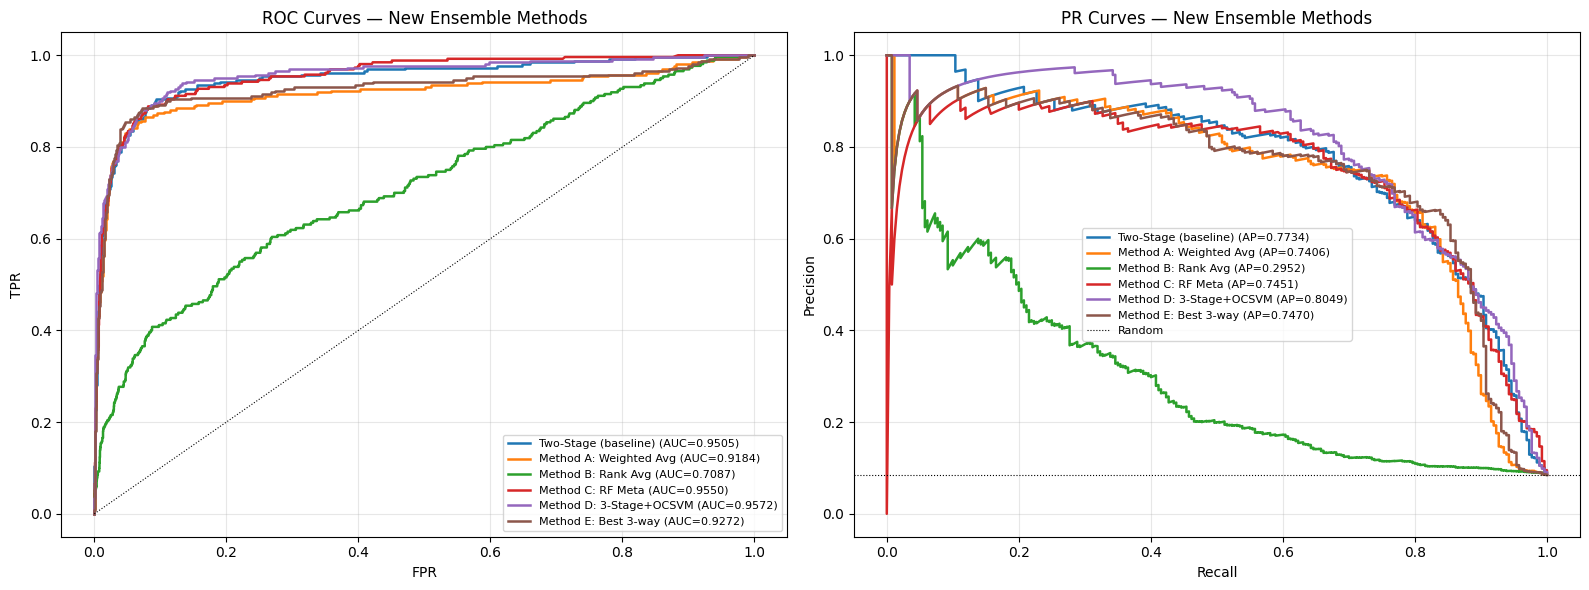

In [20]:
# ── Updated visualisations including all new methods ─────────────────────────
highlight_methods = {
    'Two-Stage (baseline)':   y_scores_two_stage if 'y_scores_two_stage' in dir() else y_cv_s1,
    'Method A: Weighted Avg': best_wt_scores,
    'Method B: Rank Avg':     rank_blend,
    'Method C: RF Meta':      y_cv_rf_meta,
    'Method D: 3-Stage+OCSVM':y_cv_3stage,
    f'Method E: Best 3-way':  best3_scores,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for name, scores in highlight_methods.items():
    fpr, tpr, _ = roc_curve(y, scores)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y,scores):.4f})", lw=1.8)
ax.plot([0,1],[0,1],'k:',lw=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves — New Ensemble Methods')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax2 = axes[1]
for name, scores in highlight_methods.items():
    pv, rv, _ = precision_recall_curve(y, scores)
    ap = average_precision_score(y, scores)
    ax2.plot(rv, pv, label=f"{name} (AP={ap:.4f})", lw=1.8)
ax2.axhline(y.mean(), color='k', linestyle=':', lw=0.8, label='Random')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('PR Curves — New Ensemble Methods')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 11. Blending Submissions (Task 3)

We save one submission per blending strategy using the best parameters found above.
All submissions use the final models fitted on **all** training data.


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# Fit final models on all training data for blending submissions
# ══════════════════════════════════════════════════════════════════════════════

print("Fitting final models on all training data ...")

# Stage 1 final (already fitted above as two_stage_final.stage1_)
# We'll use two_stage_final.stage1_ directly for all blend submissions.

# RF Meta-Learner final
ts_rf_final = TwoStageRFMeta(stage1=stage1_stack, n_estimators=200, unsup_col_idx=-1)
ts_rf_final.fit(X_with_unsup, y)

# Three-Stage + OCSVM final
ts3_final = ThreeStageEnsemble(stage1=stage1_stack, meta_C=1.0, unsup_col=-2, ocsvm_col=-1)
ts3_final.fit(X_with_ocsvm, y)

# ── OCSVM scores for test set ────────────────────────────────────────────────
# X_test_with_unsup column layout (set by build_test_features):
#   [user-item pivot (n_items) | handcrafted (N_HANDCRAFTED) | lof_norm | iso_norm | unsup_blend]
# hc_scaler was fitted on agg.values which has exactly N_HANDCRAFTED columns
# (including cosine_sim_to_normal and mahal_dist). Slicing directly from
# X_test_with_unsup avoids any column-count mismatch.
n_items_train   = user_item.shape[1]
hc_start        = n_items_train
hc_end          = n_items_train + N_HANDCRAFTED
agg_test_values = X_test_with_unsup[:, hc_start:hc_end]  # shape (n_test, N_HANDCRAFTED)

ocsvm_test_raw  = -ocsvm.decision_function(hc_scaler.transform(agg_test_values))

# Normalise using same limits derived from training normal users
_ocsvm_train_raw = -ocsvm.decision_function(hc_scaler.transform(agg.values[normal_mask]))
ocsvm_limits     = (np.percentile(_ocsvm_train_raw, 1),
                    np.percentile(_ocsvm_train_raw, 99))
ocsvm_test_norm  = percentile_normalise(ocsvm_test_raw, limits=ocsvm_limits)

X_test_with_ocsvm = np.hstack([X_test_with_unsup, ocsvm_test_norm.reshape(-1, 1)])
print("Final models fitted.")


Fitting final models on all training data ...
Final models fitted.


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# Save blending submissions
# ══════════════════════════════════════════════════════════════════════════════

print("\nGenerating blending submissions ...")

# Get Stage1 test scores (supervised arm of two_stage_final)
stage1_test_scores = two_stage_final.stage1_fitted_.predict_proba(X_test_with_unsup)[:, 1]

# Method A: Weighted Average Blend (best weights from CV)
ws_a, wl_a, wi_a, wr_a = best_wt_combo
# For test: need LOF/ISO/Recon test scores (already have them as test_lof_norm etc)
blend_a_test = (ws_a * stage1_test_scores
              + wl_a * test_lof_norm
              + wi_a * test_iso_norm
              + wr_a * test_recon_norm)
save_submission('submission_blend_WeightedAvg.npz', blend_a_test)

# Method B: Rank-Average Blend (must rank jointly with training — use sigmoid approx)
# For test we rank within the test set itself (unseen data; no leakage concern)
from scipy.stats import rankdata as _rd
blend_b_test = (  _rd(stage1_test_scores)/len(stage1_test_scores)
               + _rd(test_lof_norm)/len(test_lof_norm)
               + _rd(test_iso_norm)/len(test_iso_norm)
               + _rd(test_recon_norm)/len(test_recon_norm)
               ) / 4.0
save_submission('submission_blend_RankAvg.npz', blend_b_test)

# Method C: RF Meta-Learner
blend_c_test = ts_rf_final.predict_proba(X_test_with_unsup)[:, 1]
save_submission('submission_blend_RFMeta.npz', blend_c_test)

# Method D: Three-Stage + OCSVM
blend_d_test = ts3_final.predict_proba(X_test_with_ocsvm)[:, 1]
save_submission('submission_blend_3Stage_OCSVM.npz', blend_d_test)

# Method E: Best 3-way equal blend
_score_map_test = {
    'Stage1':  stage1_test_scores,
    'LOF':     test_lof_norm,
    'ISO':     test_iso_norm,
    'Recon':   test_recon_norm,
    'RF_meta': blend_c_test,
    'OCSVM':   ocsvm_test_norm,
}
blend_e3_test = np.mean([_score_map_test[n] for n in best3_names], axis=0)
save_submission(f'submission_blend_Best3way_{"+".join(best3_names)}.npz', blend_e3_test)

# Original two-stage (for reference)
blend_orig_test = two_stage_final.predict_proba(X_test_with_unsup)[:, 1]
save_submission('submission_two_stage_original.npz', blend_orig_test)

print("\n=== All submissions saved ===")
print("\nIndividual detector submissions:")
for f in ['submission_LGBM_LR_LOF.npz', 'submission_LGBM_LR_IsoForest.npz',
          'submission_LR_LOF.npz', 'submission_LR_IsoForest.npz',
          'submission_LOF_only.npz', 'submission_IsoForest_only.npz',
          'submission_ReconError_only.npz']:
    print(f"  {f}")
print("\nBlending submissions:")
for f in ['submission_blend_WeightedAvg.npz', 'submission_blend_RankAvg.npz',
          'submission_blend_RFMeta.npz', 'submission_blend_3Stage_OCSVM.npz',
          f'submission_blend_Best3way_{"+".join(best3_names)}.npz',
          'submission_two_stage_original.npz']:
    print(f"  {f}")



Generating blending submissions ...
  Saved submission_blend_WeightedAvg.npz  (range [0.0686, 1.1684], mean 0.3018)
  Saved submission_blend_RankAvg.npz  (range [0.1029, 0.9662], mean 0.5003)
  Saved submission_blend_RFMeta.npz  (range [0.0177, 0.9564], mean 0.1745)
  Saved submission_blend_3Stage_OCSVM.npz  (range [0.0161, 0.9855], mean 0.1799)
  Saved submission_blend_Best3way_Stage1+Recon+RF_meta.npz  (range [0.0573, 1.1237], mean 0.2726)
  Saved submission_two_stage_original.npz  (range [0.0689, 0.9840], mean 0.1872)

=== All submissions saved ===

Individual detector submissions:
  submission_LGBM_LR_LOF.npz
  submission_LGBM_LR_IsoForest.npz
  submission_LR_LOF.npz
  submission_LR_IsoForest.npz
  submission_LOF_only.npz
  submission_IsoForest_only.npz
  submission_ReconError_only.npz

Blending submissions:
  submission_blend_WeightedAvg.npz
  submission_blend_RankAvg.npz
  submission_blend_RFMeta.npz
  submission_blend_3Stage_OCSVM.npz
  submission_blend_Best3way_Stage1+Recon+RF

## 12. Final Summary — F1 Bar Chart

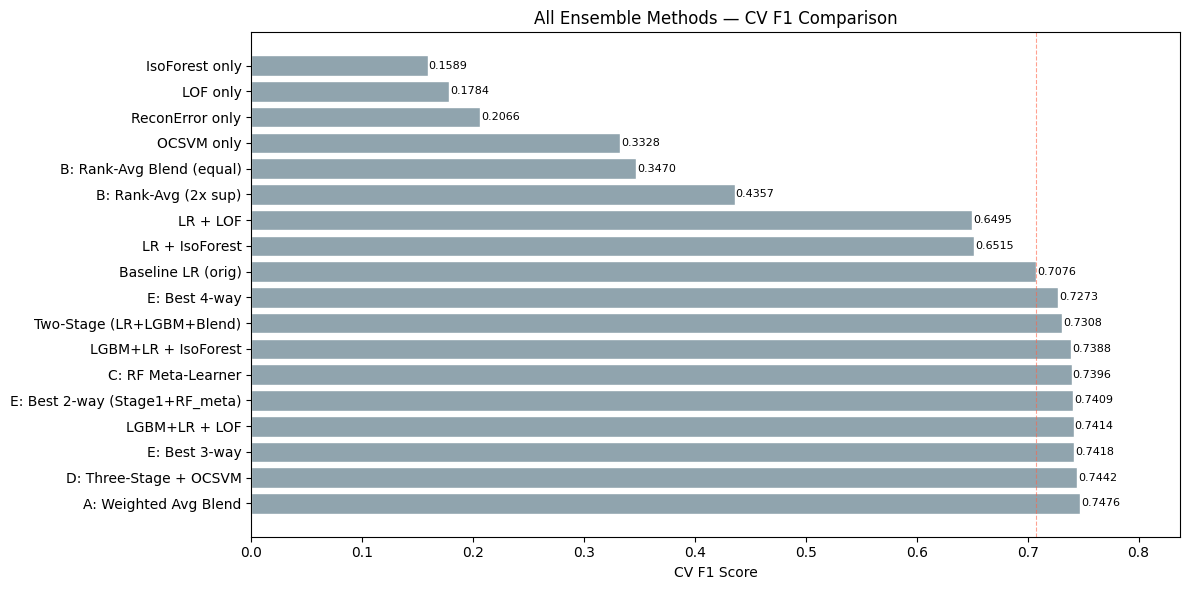

In [23]:
# ── F1 bar chart for all methods ──────────────────────────────────────────────
method_names_plot = []
method_f1_plot    = []

for name, scores, _ in all_methods:
    try:
        t = best_f1_threshold(y, scores)
        f = f1_score(y, (scores >= t).astype(int))
        method_names_plot.append(name)
        method_f1_plot.append(f)
    except:
        pass

sorted_idx = np.argsort(method_f1_plot)[::-1]
colors = ['#1976D2' if 'Method' in method_names_plot[i] else '#90A4AE'
          for i in sorted_idx]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh([method_names_plot[i] for i in sorted_idx],
               [method_f1_plot[i]    for i in sorted_idx],
               color=colors, edgecolor='white')
ax.set_xlabel('CV F1 Score'); ax.set_title('All Ensemble Methods — CV F1 Comparison')
ax.axvline(method_f1_plot[0], color='tomato', linestyle='--', lw=0.8, alpha=0.6)
for bar, val in zip(bars, [method_f1_plot[i] for i in sorted_idx]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
ax.set_xlim([0, max(method_f1_plot)*1.12])
plt.tight_layout(); plt.show()


## 14. Meta-Learner Coefficient Analysis

Fitting final Two-Stage Ensemble on ALL training data ...

Meta-LR coefficients:
  Stage 1 (supervised)     : +7.2009
  Stage 2 (unsupervised)   : +0.4303

Unsupervised weight share  : 5.6%
(A non-trivial unsupervised weight indicates Stage 2 is catching
 patterns the supervised arm misses — likely the unknown anomaly type.)


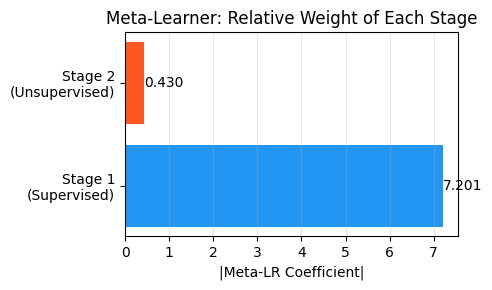

In [24]:
# ── Fit full two-stage ensemble on all training data ─────────────────────────
print("Fitting final Two-Stage Ensemble on ALL training data ...")
two_stage_final = TwoStageEnsemble(
    stage1=stage1_stack,
    meta_C=1.0,
    unsup_col_idx=UNSUP_COL_IDX,
)
two_stage_final.fit(X_with_unsup, y)

coef = two_stage_final.meta_coef_
print(f"\nMeta-LR coefficients:")
print(f"  Stage 1 (supervised)     : {coef[0]:+.4f}")
print(f"  Stage 2 (unsupervised)   : {coef[1]:+.4f}")
ratio = abs(coef[1]) / (abs(coef[0]) + abs(coef[1]) + 1e-9)
print(f"\nUnsupervised weight share  : {ratio*100:.1f}%")
print("(A non-trivial unsupervised weight indicates Stage 2 is catching")
print(" patterns the supervised arm misses — likely the unknown anomaly type.)")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.barh(['Stage 1\n(Supervised)', 'Stage 2\n(Unsupervised)'],
               [abs(coef[0]), abs(coef[1])],
               color=['#2196F3', '#FF5722'])
ax.set_xlabel('|Meta-LR Coefficient|')
ax.set_title('Meta-Learner: Relative Weight of Each Stage')
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, [abs(coef[0]), abs(coef[1])]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center')
plt.tight_layout()
plt.show()


## 15. (Optional) Tune Meta-Learner Regularisation

Grid-search over the meta-LR regularisation strength `meta_C`. This is cheap because the meta-learner only has 2 input features.

In [25]:
# ── Fast meta-C tuning ────────────────────────────────────────────────────────
# We use the OOF Stage 1 probabilities already computed and tune only the meta-LR.
# This is much faster than re-running the full two-stage CV.

from sklearn.model_selection import GridSearchCV as _GSCV

# Re-derive Stage 1 OOF probabilities
print("Computing Stage 1 OOF probabilities for meta-C tuning ...")
y_scores_s1_oof = cross_val_predict(
    stage1_stack, X_with_unsup, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict_proba',
)[:, 1]

meta_X_tune = np.column_stack([y_scores_s1_oof, unsup_score])

meta_grid = _GSCV(
    LogisticRegression(class_weight='balanced', max_iter=1000,
                       solver='lbfgs', random_state=42),
    param_grid={'C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]},
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
)
meta_grid.fit(meta_X_tune, y)

best_meta_C = meta_grid.best_params_['C']
print(f"Best meta_C : {best_meta_C}  (CV F1 = {meta_grid.best_score_:.4f})")

# Rebuild with tuned meta_C
two_stage_tuned = TwoStageEnsemble(
    stage1=stage1_stack,
    meta_C=best_meta_C,
    unsup_col_idx=UNSUP_COL_IDX,
)
y_scores_tuned = cross_val_predict(
    two_stage_tuned, X_with_unsup, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict_proba',
)[:, 1]

_p, _r, _t = precision_recall_curve(y, y_scores_tuned)
_f = np.where((_p[:-1]+_r[:-1])>0, 2*_p[:-1]*_r[:-1]/(_p[:-1]+_r[:-1]), 0)
tuned_thresh = float(_t[np.argmax(_f)])
y_pred_tuned = (y_scores_tuned >= tuned_thresh).astype(int)

print(f"\n=== Tuned Two-Stage Ensemble (meta_C={best_meta_C}) ===")
print(f"AUC       : {roc_auc_score(y, y_scores_tuned):.4f}")
print(f"F1 thresh : {tuned_thresh:.4f}")
print(f"Precision : {precision_score(y, y_pred_tuned):.4f}")
print(f"Recall    : {recall_score(y, y_pred_tuned):.4f}")
print(f"F1        : {f1_score(y, y_pred_tuned):.4f}")

Computing Stage 1 OOF probabilities for meta-C tuning ...
Best meta_C : 0.01  (CV F1 = 0.6944)

=== Tuned Two-Stage Ensemble (meta_C=0.01) ===
AUC       : 0.9519
F1 thresh : 0.6543
Precision : 0.7572
Recall    : 0.7077
F1        : 0.7316
